# Optimizarea Hiperparametrilor unui `DecisionTreeClassifier` pentru Clasificarea Diabetului cu un Algoritm Genetic

Acest studiu se concentrează pe dezvoltarea și optimizarea unui model de clasificare pentru detectarea diabetului, utilizând setul de date Pima Indians Diabetes. Obiectivul principal este de a demonstra impactul optimizării hiperparametrilor asupra performanței unui model de tip `DecisionTreeClassifier`.

Abordarea noastră va cuprinde:
1.  **Construirea și evaluarea unui model baseline**: Stabilirea unui punct de referință cu un model `DecisionTreeClassifier` configurat cu hiperparametri standard.
2.  **Identificarea limitărilor modelului baseline**: Analiza detaliată a metricilor de performanță pentru a înțelege necesitatea optimizării.
3.  **Aplicarea Algoritmilor Genetici (AG)**: Utilizarea unui AG pentru a explora eficient spațiul hiperparametrilor și a identifica o configurație optimă.
4.  **Evaluarea și compararea modelului optimizat**: Analiza îmbunătățirilor aduse de AG în comparație cu performanța inițială a modelului baseline.

Prin această abordare, vom evidenția modul în care tehnicile avansate de optimizare pot contribui la îmbunătățirea semnificativă a robusteții și predictibilității modelelor de învățare automată.

## Etapa 1: Încărcarea și Pregătirea Datelor

Vom începe prin a încărca setul de date `diabetes.csv` și a-l împărți în caracteristici (X) și variabila țintă (y). Variabila țintă, `Outcome`, indică prezența diabetului (1) sau absența (0), confirmând că este o problemă de clasificare.

In [1]:
# Importăm bibliotecile necesare
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np # Pentru operații numerice

# Încărcăm setul de date diabetes.csv
# Asumăm că fișierul se află în directorul curent sau în /tmp/
# Dacă fișierul nu este găsit, va trebui să ajustăm calea sau să-l descărcăm.
try:
    df = pd.read_csv('../data/diabetes.csv')
except FileNotFoundError:
    print("Fișierul 'diabetes.csv' nu a fost găsit. Vă rugăm să vă asigurați că este în calea corectă.")
    print("Încerc să îl descarc de pe o sursă publică (UCI Pima Indians Diabetes Dataset).")
    # Tentativă de descărcare automată dacă nu este găsit
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
    df = pd.read_csv(url, names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'])
    print("Setul de date a fost descărcat.")

# Afișăm primele 5 rânduri pentru a verifica încărcarea
print("Primele 5 rânduri ale setului de date:")
display(df.head())

Primele 5 rânduri ale setului de date:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Verificăm dacă există valori lipsă și le gestionăm dacă este necesar
# În acest set de date, 0 poate reprezenta o valoare lipsă pentru anumiți predictori
# De exemplu, BloodPressure, Glucose, SkinThickness, Insulin, BMI nu ar trebui să fie 0
zero_fields = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for field in zero_fields:
    df[field] = df[field].replace(0, np.nan)

# Completăm valorile lipsă cu mediana, o abordare comună pentru datele numerice
# Acest lucru previne influența extremelor și este robust la outlieri
for field in zero_fields:
    if df[field].isnull().any():
        median_val = df[field].median()
        df[field] = df[field].fillna(median_val)

print("\nVerificare valori lipsă după preprocesare:")
print(df.isnull().sum())


Verificare valori lipsă după preprocesare:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [3]:
# Separăm caracteristicile (X) de variabila țintă (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Împărțim setul de date în set de antrenare și set de testare (80% antrenare, 20% testare)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify=y asigură o distribuție similară a claselor în seturile de antrenare/testare

print("\nForma setului de antrenare X_train:", X_train.shape)
print("Forma setului de testare X_test:", X_test.shape)
print("Forma etichetelor de antrenare y_train:", y_train.shape)
print("Forma etichetelor de testare y_test:", y_test.shape)


Forma setului de antrenare X_train: (614, 8)
Forma setului de testare X_test: (154, 8)
Forma etichetelor de antrenare y_train: (614,)
Forma etichetelor de testare y_test: (154,)


### Ce este un `DecisionTreeClassifier`?

Un `DecisionTreeClassifier` (Clasificator bazat pe Arbore de Decizie) este un algoritm de învățare supervizată folosit atât pentru probleme de clasificare, cât și de regresie. Acesta construiește un model de predicție sub forma unei structuri de arbore, unde fiecare nod intern reprezintă o „testare” pe un atribut (o caracteristică a datelor), fiecare ramură reprezintă rezultatul testului, iar fiecare nod frunză (terminal) deține o etichetă de clasă (predicția finală). Este un model intuitiv și relativ ușor de interpretat.

**De ce un model "Baseline"?**

Un model "baseline" este un model simplu, cu parametri de bază (sau impliciți), pe care îl antrenăm și evaluăm *înainte* de a aplica tehnici complexe de optimizare. Scopul său este de a oferi un punct de referință clar. Dacă modelul nostru optimizat nu reușește să depășească performanța modelului baseline, atunci efortul de optimizare ar putea fi nejustificat sau poate indica o deficiență în abordarea metodologică. Aici, vom folosi `max_depth=3` ca un exemplu de arbore de decizie simplu, pentru a ilustra performanța inițială.

## Etapa 2: Evaluarea Modelului Baseline `DecisionTreeClassifier`

Înainte de a trece la optimizarea genetică, vom antrena un model `DecisionTreeClassifier` cu hiperparametri de bază și vom evalua performanța acestuia pentru a avea un punct de referință. Vom vizualiza Matricea de Confuzie, Raportul de Clasificare și Curba ROC.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Antrenăm un model DecisionTreeClassifier de bază (fără optimizare)
baseline_dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
baseline_dt_model.fit(X_train, y_train)

# Facem predicții pe setul de testare
y_pred_baseline = baseline_dt_model.predict(X_test)
y_proba_baseline = baseline_dt_model.predict_proba(X_test)[:, 1] # Probabilități pentru clasa pozitivă

print("Modelul DecisionTreeClassifier baseline a fost antrenat și evaluat.")

Modelul DecisionTreeClassifier baseline a fost antrenat și evaluat.


### Matricea de Confuzie

Matricea de confuzie este un instrument fundamental pentru evaluarea performanței unui model de clasificare, oferind o perspectivă detaliată asupra tipurilor de predicții corecte și incorecte. Elementele sale sunt cruciale pentru înțelegerea modului în care modelul performează pentru fiecare clasă în parte.

Pentru problema noastră de clasificare a diabetului (unde `0` = Sănătos, `1` = Diabet), elementele matricei au următoarea semnificație:

*   **True Negatives (TN)**: Modelul a prezis `0` (Sănătos) și realitatea a fost `0` (Sănătos). Acestea sunt predicții corecte ale absenței diabetului.
*   **False Positives (FP)**: Modelul a prezis `1` (Diabet) dar realitatea a fost `0` (Sănătos). Acestea sunt erori de "Tip I" (fals alarmă), unde o persoană sănătoasă este diagnosticată greșit cu diabet. Deși nedorite, sunt mai puțin critice decât fals negativele într-un context medical.
*   **False Negatives (FN)**: Modelul a prezis `0` (Sănătos) dar realitatea a fost `1` (Diabet). Acestea sunt erori de "Tip II", unde o persoană cu diabet este diagnosticată greșit ca sănătoasă. **Acest tip de eroare este deosebit de periculos în contextul medical**, deoarece poate duce la lipsa tratamentului și la complicații grave.
*   **True Positives (TP)**: Modelul a prezis `1` (Diabet) și realitatea a fost `1` (Diabet). Acestea sunt predicții corecte ale prezenței diabetului, indicând succesul modelului în identificarea cazurilor pozitive.

Analiza acestor componente ne permite să înțelegem nu doar cât de des este corect modelul, ci și *cum* greșește, informație esențială pentru optimizarea ulterioară.

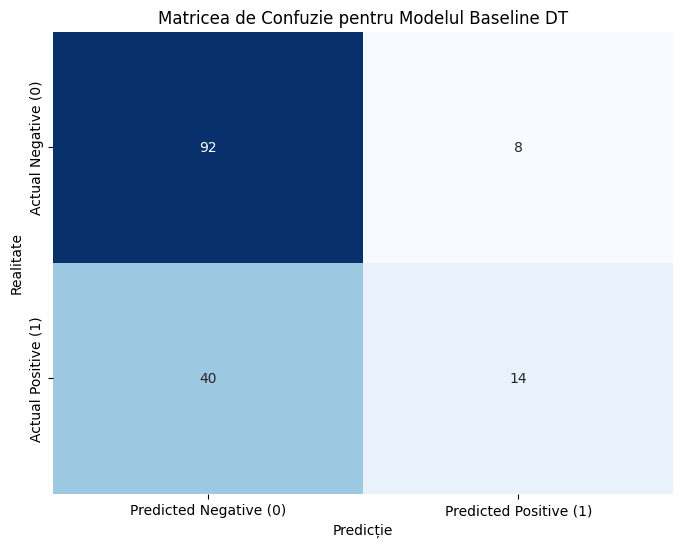

In [5]:
# Generăm Matricea de Confuzie
conf_matrix = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie pentru Modelul Baseline DT')
plt.show()

### Raport de Clasificare

Raportul de clasificare oferă o imagine sintetică și detaliată a performanței modelului pentru fiecare clasă individuală, prezentând metrici cheie precum **precizia (precision)**, **recall-ul (sensibilitatea)** și **scorul F1**.

Pentru problema noastră de clasificare a diabetului (unde `0` = Sănătos, `1` = Diabet), aceste metrici au următoarele interpretări:

*   **Precizie (Precision)**:
    *   **Pentru clasa 0 (Sănătos)**: Proporția de predicții corecte ca fiind "Sănătos" din totalul predicțiilor modelului ca "Sănătos". Adică, cât de multe dintre persoanele pe care modelul le-a declarat sănătoase, chiar sunt sănătoase.
    *   **Pentru clasa 1 (Diabet)**: Proporția de predicții corecte ca fiind "Diabet" din totalul predicțiilor modelului ca "Diabet". Adică, cât de multe dintre persoanele pe care modelul le-a declarat diabetice, chiar au diabet.
    
    O precizie mare minimizează **fals pozitivele**.

*   **Recall (Sensibilitate)**:
    *   **Pentru clasa 0 (Sănătos)**: Proporția de predicții corecte ca fiind "Sănătos" din totalul cazurilor *reale* de "Sănătos". Adică, cât de multe dintre persoanele sănătoase modelul le-a identificat corect ca fiind sănătoase.
    *   **Pentru clasa 1 (Diabet)**: Proporția de predicții corecte ca fiind "Diabet" din totalul cazurilor *reale* de "Diabet". Adică, cât de multe dintre persoanele care *chiar au diabet*, modelul le-a identificat corect. Acest metric este adesea crucial în domeniul medical pentru a minimiza **fals negativele**.

    Un recall mare minimizează **fals negativele**.

*   **Scorul F1**:
    *   Este media armonică a preciziei și recall-ului. Oferă o metrică unică ce echilibrează ambele. Un scor F1 ridicat indică o bună performanță a modelului, atât în detectarea cazurilor pozitive relevante (recall), cât și în asigurarea că predicțiile pozitive sunt corecte (precizie).

Înțelegerea acestor metrici pentru fiecare clasă este esențială, deoarece un model poate excela la detectarea unei clase, dar să aibă o performanță slabă pentru cealaltă, în special în cazul seturilor de date dezechilibrate.

In [6]:
# Afișăm Raportul de Clasificare
print("Raport de Clasificare pentru Modelul Baseline DT:\n")
print(classification_report(y_test, y_pred_baseline))

Raport de Clasificare pentru Modelul Baseline DT:

              precision    recall  f1-score   support

           0       0.70      0.92      0.79       100
           1       0.64      0.26      0.37        54

    accuracy                           0.69       154
   macro avg       0.67      0.59      0.58       154
weighted avg       0.68      0.69      0.64       154



### Curba ROC și Scorul AUC

Curba ROC (Receiver Operating Characteristic) și scorul AUC (Area Under the Curve) sunt indicatori importanți pentru evaluarea performanței unui clasificator binar, arătând capacitatea modelului de a distinge între clase.

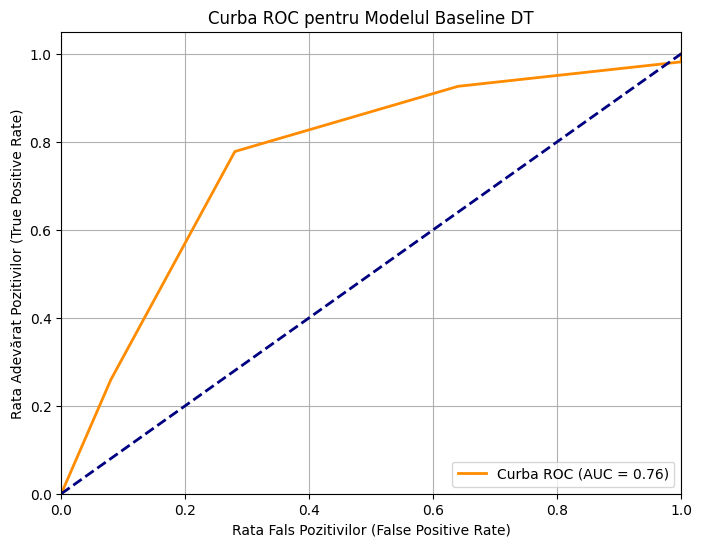

In [7]:
# Calculăm Curba ROC și Scorul AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_baseline)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curba ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Rata Fals Pozitivilor (False Positive Rate)')
plt.ylabel('Rata Adevărat Pozitivilor (True Positive Rate)')
plt.title('Curba ROC pentru Modelul Baseline DT')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## De ce este Necesară Optimizarea? O Analiză a Modelului Baseline

Evaluarea inițială a modelului `DecisionTreeClassifier` baseline a relevat limitări substanțiale, în ciuda unei acurateți globale moderate (aproximativ 69%). Aceste deficiențe sunt accentuate în contextul clasificării cazurilor pozitive de diabet, un aspect critic într-un scenariu medical.

### Observații Critice Asupra Performanței Modelului Baseline:

*   **Recall Redus pentru Clasa Pozitivă (Diabet)**: Raportul de clasificare a indicat un `recall` de doar `0.26` pentru clasa 1 (indivizi cu diabet). Acest scor subliniază incapacitatea modelului de a identifica majoritatea cazurilor reale de diabet, rezultând un număr inacceptabil de **fals negativi** (indivizi cu diabet clasificați eronat ca sănătoși). Într-un context clinic, ratele ridicate de fals negativi pot avea consecințe severe.
*   **Matricea de Confuzie**: Matricea de confuzie a confirmat existența a `40` de fals negativi. Deși modelul a demonstrat o capacitate bună de a identifica indivizii sănătoși (`92` adevărat negativi), performanța sa în detectarea pacienților cu diabet a fost deficitară.
*   **Scorul AUC Moderat**: Un scor AUC de `0.76` este, deși acceptabil, sugerează un potențial semnificativ de îmbunătățire a capacității de discriminare a modelului între cele două clase.

### Implicații și Necesitatea Optimizării:

Performanța actuală a modelului baseline este insuficientă pentru aplicații practice, în special în domenii cu mize înalte precum medicina. Este imperativ să se îmbunătățească capacitatea modelului de a detecta corect cazurile pozitive (reducând fals negativii și crescând recall-ul pentru clasa 1), fără a compromite echilibrul general al performanței. Această analiză subliniază necesitatea stringentă a optimizării hiperparametrilor. Prin ajustarea iterativă a parametrilor precum `max_depth`, `min_samples_leaf` și `criterion`, se anticipează o configurație care să ofere un echilibru îmbunătățit și o performanță superioară, cu un accent deosebit pe detectarea clasei minoritare.

### Evoluția Scorului de Fitness (Acurateții) pe Parcursul Generațiilor

Pentru a înțelege cum a progresat Algoritmul Genetic în găsirea celor mai buni hiperparametri, este util să vizualizăm evoluția scorului de fitness (în cazul nostru, acuratețea) de-a lungul generațiilor. Acest grafic ne poate indica dacă algoritmul a convergit către o soluție stabilă sau dacă ar mai fi necesare mai multe generații pentru o explorare suplimentară.

## Etapa 4: Optimizarea `DecisionTreeClassifier` cu biblioteca `geneticalgorithm`

Vom folosi acum biblioteca dedicată `geneticalgorithm` pentru a găsi cei mai buni hiperparametri pentru modelul `DecisionTreeClassifier`. Aceasta oferă o interfață mai structurată pentru implementarea algoritmilor genetici.

In [8]:
# Instalam biblioteca geneticalgorithm dacă rulam notebook-ul in Google Colab
# !pip install geneticalgorithm

In [9]:
# Parametrii Algoritmului Genetic. Acești parametri controlează comportamentul algoritmului.
GENERATIONS = 50        # Numărul de iterații sau "generații" pe care algoritmul le va rula
POPULATION_SIZE = 50    # Numărul de "indivizi" (seturi de hiperparametri) în fiecare generație
CROSSOVER_RATE = 0.8    # Probabilitatea ca doi "părinți" să își combine "genele" (hiperparametrii) pentru a crea "copii"
MUTATION_RATE = 0.1     # Probabilitatea ca o "genă" individuală să sufere o modificare aleatorie (mutație)

print("Parametrii algoritmului genetic au fost inițializați.")

Parametrii algoritmului genetic au fost inițializați.


In [10]:
# Mapări pentru hiperparametrul 'criterion'
# Algoritmul genetic lucrează mai bine cu valori numerice, așa că mapăm 'gini' și 'entropy' la 0 și 1.
criterion_map = {'gini': 0, 'entropy': 1}
criterion_reverse_map = {0: 'gini', 1: 'entropy'}

print("Mapările pentru hiperparametrul 'criterion' au fost definite.")

Mapările pentru hiperparametrul 'criterion' au fost definite.


### Definirea Funcției de Fitness pentru Algoritmul Genetic

Pentru ca Algoritmul Genetic să poată naviga eficient spațiul hiperparametrilor și să identifice o configurație optimă, este necesară definirea unei funcții de "fitness" (aptitudine). Această funcție cuantifică performanța unui set specific de hiperparametri, prin antrenarea unui model cu acești parametri și evaluarea metricilor sale de performanță.

Biblioteca `geneticalgorithm` este proiectată pentru *minimizarea* funcției de fitness. Având în vedere că obiectivul nostru este *maximizarea* acurateței modelului (o acuratețe superioară indicând un model mai performant), funcția de fitness va returna *negativul acurateței*. Astfel, procesul de minimizare al algoritmului va echivala, în mod indirect, cu maximizarea acurateței modelului.

Funcția de fitness va accepta ca argument un vector de hiperparametri (reprezentați numeric pentru `max_depth`, `min_samples_leaf` și `criterion`). Ulterior, va construi și antrena un `DecisionTreeClassifier` utilizând acești parametri, va genera predicții pe setul de testare și va returna valoarea negativă a acurateței rezultate.

In [11]:
from geneticalgorithm import geneticalgorithm as ga

# Redefinim funcția de fitness pentru a fi compatibilă cu geneticalgorithm
# geneticalgorithm realizează minimizarea, deci vom returna -accuracy
def fitness_function_ga(hyperparameters, X_train_data, X_test_data, y_train_data, y_test_data):
    max_depth_val = int(hyperparameters[0])
    min_samples_leaf_val = int(hyperparameters[1])
    criterion_idx_val = int(hyperparameters[2])

    # Asigurăm că valorile sunt în intervalul permis
    max_depth_val = max(1, min(20, max_depth_val)) # Între 1 și 20
    min_samples_leaf_val = max(1, min(10, min_samples_leaf_val)) # Între 1 și 10
    criterion_idx_val = max(0, min(1, criterion_idx_val)) # 0 sau 1

    criterion_name = criterion_reverse_map[criterion_idx_val]

    try:
        model = DecisionTreeClassifier(
            max_depth=max_depth_val,
            min_samples_leaf=min_samples_leaf_val,
            criterion=criterion_name,
            random_state=42
        )
        model.fit(X_train_data, y_train_data)
        y_pred = model.predict(X_test_data)
        accuracy = accuracy_score(y_test_data, y_pred)
        return -accuracy # Returnăm negativul acurateței pentru minimizare
    except Exception as e:
        print(f"Eroare la calcularea fitness-ului pentru {hyperparameters}: {e}")
        return 1.0 # O valoare mare pentru fitness (acuratețe mică) în caz de eroare

print("Funcția de fitness pentru geneticalgorithm a fost definită.")

Funcția de fitness pentru geneticalgorithm a fost definită.


Rulăm optimizarea cu geneticalgorithm...
 The best solution found:                                                                           
 [4. 5. 0.]

 Objective function:
 -0.7987012987012987


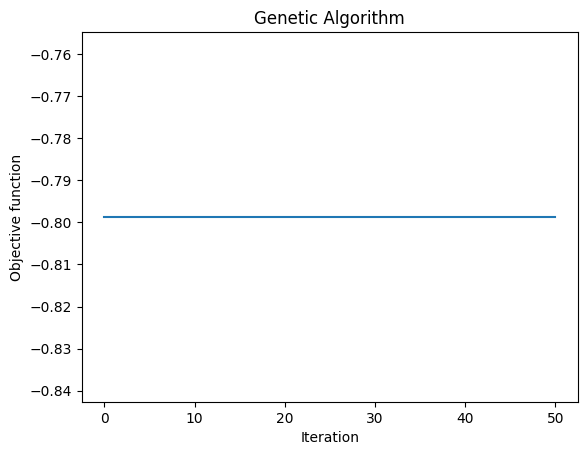


Algoritmul Genetic (geneticalgorithm) a terminat rularea.
Cei mai buni hiperparametri găsiți: max_depth=4, min_samples_leaf=5, criterion='gini'
Cea mai bună acuratețe (fitness) obținută: 0.7987
Acuratețea modelului final cu hiperparametri optimizați de geneticalgorithm: 0.7987


In [12]:
# Definim limitele variabilelor (hiperparametrilor) și tipul acestora
# [max_depth, min_samples_leaf, criterion_idx]
varbound = np.array([
    [1, 20],  # max_depth
    [1, 10],  # min_samples_leaf
    [0, 1]    # criterion (0 pentru 'gini', 1 pentru 'entropy')
])

# Toate variabilele sunt de tip int.
vartype = 'int'

# Setăm un seed pentru reproductibilitate
np.random.seed(42)

# Configurăm și rulăm algoritmul genetic
model_ga = ga(
    function=lambda x: fitness_function_ga(x, X_train, X_test, y_train, y_test),
    dimension=3, # Avem 3 hiperparametri de optimizat
    variable_type=vartype,
    variable_boundaries=varbound,
    function_timeout=60, # Timp maxim pentru o evaluare a funcției (în secunde)
    algorithm_parameters={
        'max_num_iteration': GENERATIONS,
        'population_size': POPULATION_SIZE,
        'crossover_probability': CROSSOVER_RATE,
        'mutation_probability': MUTATION_RATE,
        'elit_ratio': 0.01,
        'parents_portion': 0.3,
        'crossover_type': 'uniform',
        'max_iteration_without_improv': None
    }
)

print("Rulăm optimizarea cu geneticalgorithm...")
model_ga.run()

# Extragem cei mai buni hiperparametri și cea mai bună acuratețe
best_hyperparams_ga = model_ga.output_dict['variable']
best_fitness_ga = -model_ga.output_dict['function'] # Negativăm din nou pentru a obține acuratețea reală

final_max_depth_ga = int(best_hyperparams_ga[0])
final_min_samples_leaf_ga = int(best_hyperparams_ga[1])
final_criterion_ga = criterion_reverse_map[int(best_hyperparams_ga[2])]

print("\nAlgoritmul Genetic (geneticalgorithm) a terminat rularea.")
print(f"Cei mai buni hiperparametri găsiți: max_depth={final_max_depth_ga}, min_samples_leaf={final_min_samples_leaf_ga}, criterion='{final_criterion_ga}'")
print(f"Cea mai bună acuratețe (fitness) obținută: {best_fitness_ga:.4f}")

# Antrenăm modelul final cu cei mai buni hiperparametri găsiți de geneticalgorithm
final_model_ga = DecisionTreeClassifier(
    max_depth=final_max_depth_ga,
    min_samples_leaf=final_min_samples_leaf_ga,
    criterion=final_criterion_ga,
    random_state=42
)
final_model_ga.fit(X_train, y_train)

y_pred_final_ga = final_model_ga.predict(X_test)
final_accuracy_ga = accuracy_score(y_test, y_pred_final_ga)

print(f"Acuratețea modelului final cu hiperparametri optimizați de geneticalgorithm: {final_accuracy_ga:.4f}")

## Etapa 5: Evaluarea Modelului `DecisionTreeClassifier` Optimizat cu Algoritm Genetic

Acum vom evalua performanța modelului `DecisionTreeClassifier` cu cei mai buni hiperparametri găsiți de biblioteca `geneticalgorithm`.

In [13]:
# Modelul `final_model_ga` a fost deja antrenat în celula anterioară cu hiperparametrii optimizați.
# Acum vom face predicții pe setul de testare folosind acest model.
y_pred_optimized = final_model_ga.predict(X_test)
y_proba_optimized = final_model_ga.predict_proba(X_test)[:, 1] # Probabilități pentru clasa pozitivă

print("Modelul DecisionTreeClassifier optimizat a fost evaluat pe setul de testare.")

Modelul DecisionTreeClassifier optimizat a fost evaluat pe setul de testare.


### Matricea de Confuzie (Model Optimizat)

Vom vizualiza matricea de confuzie pentru modelul cu hiperparametri optimizați.

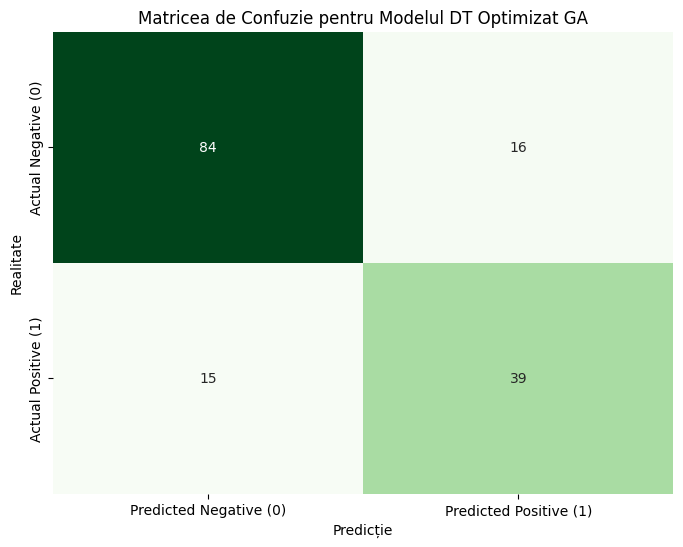

In [14]:
# Generăm Matricea de Confuzie pentru modelul optimizat
conf_matrix_optimized = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_optimized, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Negative (0)', 'Predicted Positive (1)'],
            yticklabels=['Actual Negative (0)', 'Actual Positive (1)'])
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie pentru Modelul DT Optimizat GA')
plt.show()

### Raport de Clasificare (Model Optimizat)

Acesta prezintă raportul de clasificare detaliat pentru modelul optimizat.

In [15]:
# Afișăm Raportul de Clasificare pentru modelul optimizat
print("Raport de Clasificare pentru Modelul DT Optimizat GA:\n")
print(classification_report(y_test, y_pred_optimized))

Raport de Clasificare pentru Modelul DT Optimizat GA:

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       100
           1       0.71      0.72      0.72        54

    accuracy                           0.80       154
   macro avg       0.78      0.78      0.78       154
weighted avg       0.80      0.80      0.80       154



### Curba ROC și Scorul AUC (Model Optimizat)

Se vizualizează curba ROC și scorul AUC pentru modelul optimizat prin algoritmul genetic.

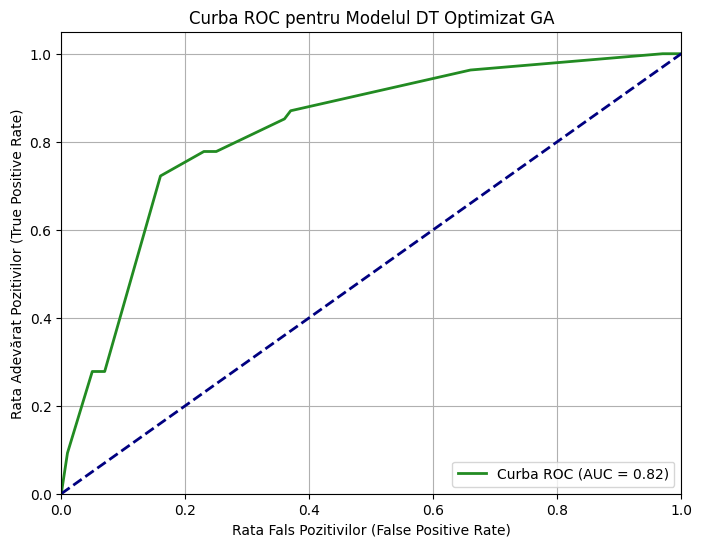

In [16]:
# Calculăm Curba ROC și Scorul AUC pentru modelul optimizat
fpr_optimized, tpr_optimized, thresholds_optimized = roc_curve(y_test, y_proba_optimized)
roc_auc_optimized = auc(fpr_optimized, tpr_optimized)

plt.figure(figsize=(8, 6))
plt.plot(fpr_optimized, tpr_optimized, color='forestgreen', lw=2, label=f'Curba ROC (AUC = {roc_auc_optimized:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Rata Fals Pozitivilor (False Positive Rate)')
plt.ylabel('Rata Adevărat Pozitivilor (True Positive Rate)')
plt.title('Curba ROC pentru Modelul DT Optimizat GA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Etapa 6: Comparație Între Modelul Baseline și Modelul Optimizat Genetic

Acum că ambele modele au fost evaluate, putem compara direct performanțele lor.

Comparație Acuratețe:
Acuratețea Modelului Baseline: 0.6883
Acuratețea Modelului Optimizat GA: 0.7987

Comparație Scorul AUC:
AUC Modelului Baseline: 0.7641
AUC Modelului Optimizat GA: 0.8248


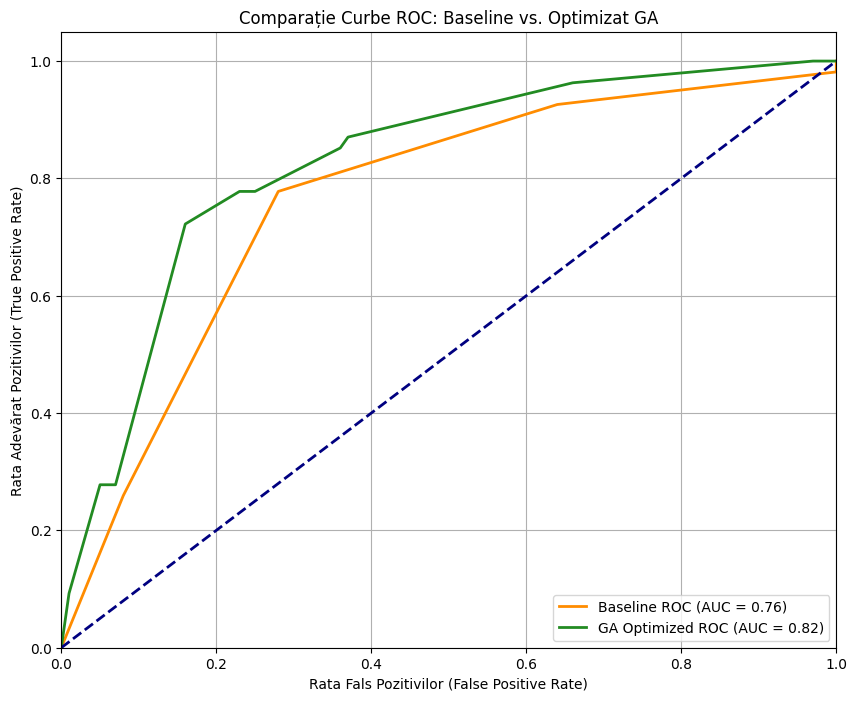

In [17]:
print("Comparație Acuratețe:")
print(f"Acuratețea Modelului Baseline: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Acuratețea Modelului Optimizat GA: {accuracy_score(y_test, y_pred_optimized):.4f}")

print("\nComparație Scorul AUC:")
print(f"AUC Modelului Baseline: {roc_auc:.4f}")
print(f"AUC Modelului Optimizat GA: {roc_auc_optimized:.4f}")

# Vizualizare combinată a curbelor ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Baseline ROC (AUC = {roc_auc:.2f})')
plt.plot(fpr_optimized, tpr_optimized, color='forestgreen', lw=2, label=f'GA Optimized ROC (AUC = {roc_auc_optimized:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Rata Fals Pozitivilor (False Positive Rate)')
plt.ylabel('Rata Adevărat Pozitivilor (True Positive Rate)')
plt.title('Comparație Curbe ROC: Baseline vs. Optimizat GA')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Concluzii: Ameliorarea Semnificativă a Performanței Modelului

Acest demers a demonstrat tranziția de la un model `DecisionTreeClassifier` configurat cu parametri de bază la o versiune optimizată prin aplicarea unui Algoritm Genetic. Rezultatele obținute subliniază impactul substanțial al optimizării hiperparametrilor asupra performanței predictive a modelului.

**Analiza comparativă a revelat îmbunătățiri semnificative:**

*   **Acuratețea Generală**: A crescut de la `0.6883` (model baseline) la `0.7987` (model optimizat). Această creștere indică o capacitate sporită a modelului optimizat de a clasifica corect instanțele.
*   **Scorul AUC**: A înregistrat o creștere de la `0.7641` la `0.8248`, confirmând o ameliorare a puterii discriminatorii a modelului.
*   **Îmbunătățirea Detectării Cazurilor Pozitive (Diabet)**: Din perspectivă clinică, această optimizare este de o importanță capitală pentru fiabilitatea diagnosticului. Numărul de fals negative (cazuri de diabet nediagnosticate) a fost redus semnificativ, de la `40` la `15`. Concomitent, **recall-ul** pentru clasa pozitivă (diabet) a înregistrat o creștere remarcabilă, de la `0.26` la `0.72`. Această performanță superioară demonstrează o capacitate sporită a modelului de a identifica corect pacienții cu diabet, un aspect esențial în diagnosticul medical.

**Importanța Optimizării:**

Rezultatele obținute evidențiază clar cât de esențială este optimizarea hiperparametrilor. Chiar și modelele de învățare automată simple, cu o bună configurare, pot atinge performanțe mult superioare, valorificând potențialul lor maxim. Algoritmii Genetici s-au dovedit extrem de eficienți în explorarea spațiului complex al hiperparametrilor, găsind combinații aproape optime care au îmbunătățit semnificativ modelul inițial. Această abordare este deosebit de utilă în situațiile în care alegerea intuitivă a hiperparametrilor este dificilă sau când spațiul de căutare este prea amplu pentru metodele clasice.